In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression

In [4]:
df = pd.read_excel('catalog_products.xlsx')

In [5]:
# 1

In [6]:
print(df.head(5))
print(df.dtypes)


    col_1  col_2  col_3        col_4  col_5  col_6     col_7  col_8  col_9  \
0    Home    762    303  Electronics     49    348  Clothing    206    123   
1  Sports    190     34       Sports    107     99  Clothing    836    775   
2   Books    711      2         Home     93    876      Home    868     69   
3  Sports    484    362        Books    636    361      Home    897    111   
4  Sports    733    195         Home    829    937  Clothing    428    871   

        col_10  ...  col_41  col_42    col_43  col_44  col_45       col_46  \
0       Sports  ...     676     471      Home     511     424  Electronics   
1  Electronics  ...     700     696     Books     329     677  Electronics   
2        Books  ...     418     596      Home     781     622  Electronics   
3     Clothing  ...     620     357      Home     811     240     Clothing   
4         Home  ...     740     845  Clothing     272     143  Electronics   

   col_47  col_48       col_49  col_50  
0     511     484    

In [7]:
rows = df.shape[0]
cols = df.shape[1]
print('Строк:', rows)
print('Столбцы:', cols)


Строк: 10000
Столбцы: 50


In [8]:
print(df.isnull().sum())

col_1     0
col_2     0
col_3     0
col_4     0
col_5     0
col_6     0
col_7     0
col_8     0
col_9     0
col_10    0
col_11    0
col_12    0
col_13    0
col_14    0
col_15    0
col_16    0
col_17    0
col_18    0
col_19    0
col_20    0
col_21    0
col_22    0
col_23    0
col_24    0
col_25    0
col_26    0
col_27    0
col_28    0
col_29    0
col_30    0
col_31    0
col_32    0
col_33    0
col_34    0
col_35    0
col_36    0
col_37    0
col_38    0
col_39    0
col_40    0
col_41    0
col_42    0
col_43    0
col_44    0
col_45    0
col_46    0
col_47    0
col_48    0
col_49    0
col_50    0
dtype: int64


In [9]:
#2

In [10]:
df['col_2'] = df['col_2'].astype(float)
df['col_2'] = df['col_2'].fillna(df['col_2'].mean())

df= df.dropna(subset=['col_2'])

print(df['col_2'])

0       762.0
1       190.0
2       711.0
3       484.0
4       733.0
        ...  
9995    444.0
9996    434.0
9997    228.0
9998    509.0
9999    799.0
Name: col_2, Length: 10000, dtype: float64


In [11]:
#3


In [12]:
df['total_price'] = df['col_2'] * df['col_3']
col_2 = df['col_2']
df['log_price'] = np.log(col_2)
df['double_stock'] = df['col_3'] * 2

df = df[['total_price', 'log_price', 'double_stock']]

print(df.head(5))

   total_price  log_price  double_stock
0     230886.0   6.635947           606
1       6460.0   5.247024            68
2       1422.0   6.566672             4
3     175208.0   6.182085           724
4     142935.0   6.597146           390


In [13]:
#4
df = pd.read_excel('catalog_products.xlsx')


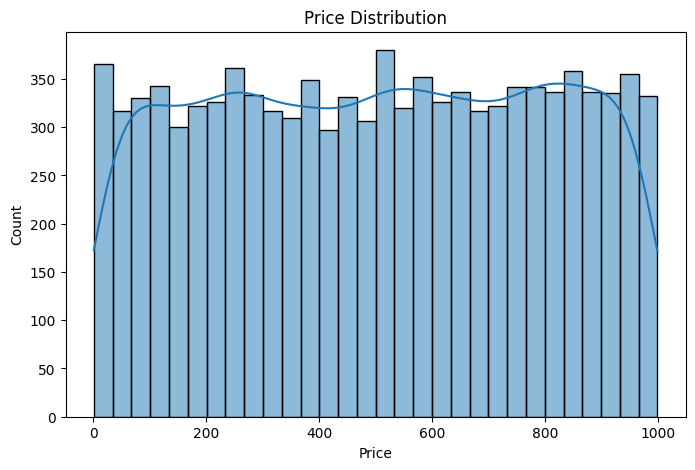

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['col_2'], bins=30, kde=True)

plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

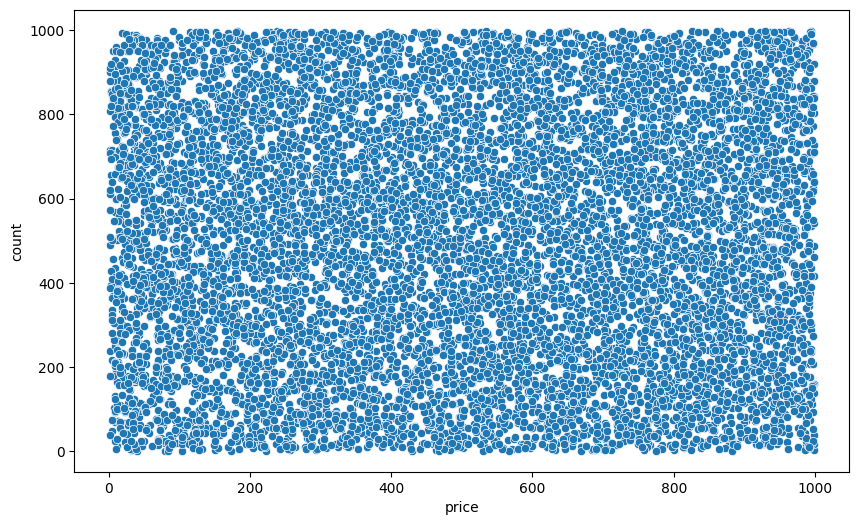

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['col_2'], y=df['col_3'], data=df)

plt.xlabel('price')
plt.ylabel('count')

plt.show()

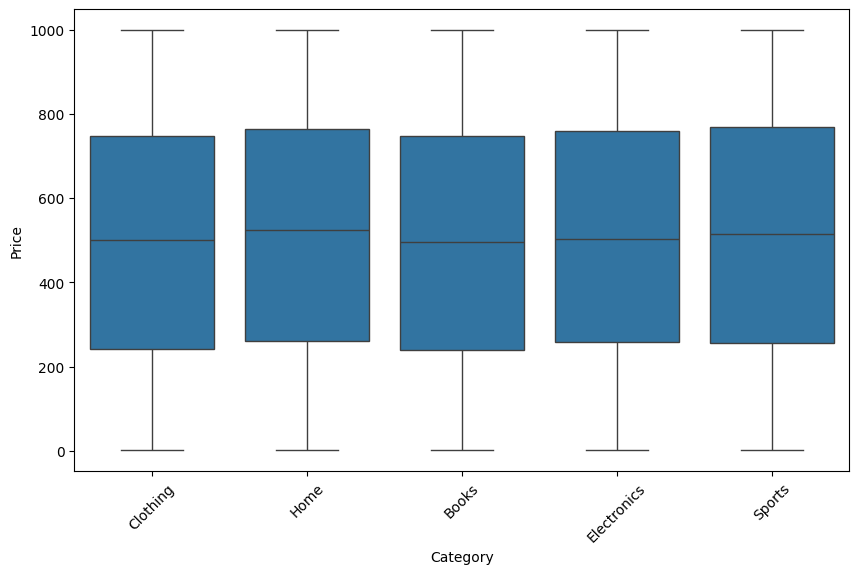

In [16]:
plt.figure(figsize=(10,6))
sns.boxplot(x='col_7', y='col_2', data=df)

plt.xlabel('Category')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.show()

In [17]:
#5

In [18]:
price_high =  df['col_2'].mean() + 3*df['col_2'].std()
price_low = df['col_2'].mean() - 3 *df['col_2'].std()

anomalies = df[
    (df['col_2'] > price_high) |
    (df['col_2'] < price_low)
]


print(anomalies)

print('Clean head')
print(anomalies.head())

Empty DataFrame
Columns: [col_1, col_2, col_3, col_4, col_5, col_6, col_7, col_8, col_9, col_10, col_11, col_12, col_13, col_14, col_15, col_16, col_17, col_18, col_19, col_20, col_21, col_22, col_23, col_24, col_25, col_26, col_27, col_28, col_29, col_30, col_31, col_32, col_33, col_34, col_35, col_36, col_37, col_38, col_39, col_40, col_41, col_42, col_43, col_44, col_45, col_46, col_47, col_48, col_49, col_50]
Index: []

[0 rows x 50 columns]
Clean head
Empty DataFrame
Columns: [col_1, col_2, col_3, col_4, col_5, col_6, col_7, col_8, col_9, col_10, col_11, col_12, col_13, col_14, col_15, col_16, col_17, col_18, col_19, col_20, col_21, col_22, col_23, col_24, col_25, col_26, col_27, col_28, col_29, col_30, col_31, col_32, col_33, col_34, col_35, col_36, col_37, col_38, col_39, col_40, col_41, col_42, col_43, col_44, col_45, col_46, col_47, col_48, col_49, col_50]
Index: []

[0 rows x 50 columns]


In [19]:
#6


In [20]:
le = LabelEncoder()
df['col_7'] = le.fit_transform(df['col_7'])

df = df[['col_7']]

print(df.head())

   col_7
0      1
1      1
2      3
3      3
4      1


In [21]:
#7
df = pd.read_excel('catalog_products.xlsx')

In [22]:
y = df['col_2']
X = df.drop(columns=['col_2'])

X = pd.get_dummies(X, drop_first=False)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state=42
)
print('X_train:', X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (8000, 117)
X_test : (2000, 117)
y_train: (8000,)
y_test : (2000,)


In [23]:
#8


In [24]:

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("Prediction:", y_pred[:10])
print("MAE:", mae)
print("MSE:", mse)

Prediction: [551.14415251 592.96318129 486.68928172 474.98086536 533.32067997
 485.7068938  535.83535655 449.10079208 535.53813326 450.84692264]
MAE: 250.89656993869926
MSE: 84085.18444030188


In [25]:
#9

In [51]:
df_model = df.copy()

df_model['total_value'] = df_model['col_2'] * df_model['col_3']
df_model['double_stock'] = df_model['col_3'] * 2
df_model['log_price'] = np.log1p(df_model['col_2'])

df_model = pd.get_dummies(df_model, drop_first=True)


X = df_model.drop(columns=['col_2'])
y = df_model['col_2']

In [27]:
#11

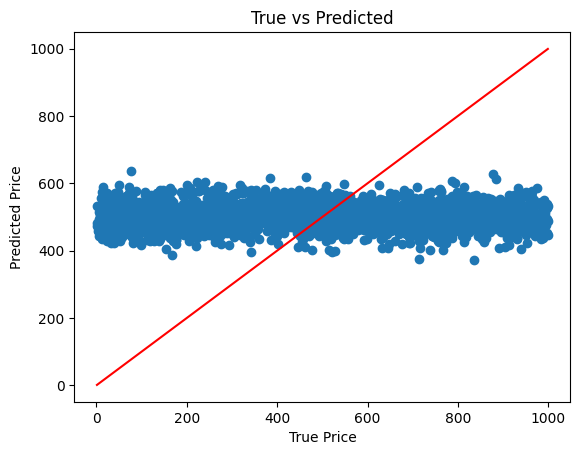

In [28]:
plt.scatter(y_test, y_pred)
plt.xlabel("True Price")
plt.ylabel("Predicted Price")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.title("True vs Predicted")
plt.show()

In [29]:
#12

In [31]:
from sklearn.preprocessing import StandardScaler

num_cols = ['col_2', 'col_3', 'total_value', 'double_stock', 'log_price']

scaler = StandardScaler()
df_model[num_cols] = scaler.fit_transform(df_model[num_cols])
print(df_model[num_cols].mean())

col_2           1.563194e-17
col_3          -1.101341e-17
total_value    -1.136868e-17
double_stock   -1.101341e-17
log_price       1.509903e-17
dtype: float64


In [34]:
#13

In [ ]:
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pd.read_excel('catalog_products.xlsx').select_dtypes('number')
X, y = df.drop(columns=['col_2']), df['col_2']

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)


model = LinearRegression().fit(X_poly, y)
pred = model.predict(X_poly)

print(f"Признаков: {X_poly.shape[1]}")
print(f"MAE: {mean_absolute_error(y, pred):.2f}")
print(f"MSE: {mean_squared_error(y, pred):.2f}")

Признаков: 560
MAE: 241.20
MSE: 79252.54


In [36]:
#14

In [15]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Берем только числа (чтобы не было ошибки 'Clothing')
X = df.select_dtypes('number').drop(columns=['col_2'])
y = df['col_2']

# 2. Масштабирование (ОБЯЗАТЕЛЬНО для KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Сплит данных (используем те же X_scaled)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 4. Обучение KNN
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

# 5. Предсказание и метрики
y_pred = knn.predict(X_test)
print(f"KNN MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"KNN MSE: {mean_squared_error(y_test, y_pred):.2f}")

KNN MAE: 263.71
KNN MSE: 97435.55


In [38]:
#15

In [39]:
results = {}

for cat in df['col_7'].unique():
    temp = df[df['col_7'] == cat].copy()

    X = temp[['col_3']]
    y = temp['col_2']

    X_train, X_test, y_train, y_test = train_test_split(X, y)

    model = LinearRegression()
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    results[cat] = mean_absolute_error(y_test, pred)

print(results)

{'Clothing': 249.3301903354152, 'Home': 248.14435523691657, 'Books': 254.4959570089597, 'Electronics': 253.75282143071678, 'Sports': 252.15011024164966}


In [40]:
#16

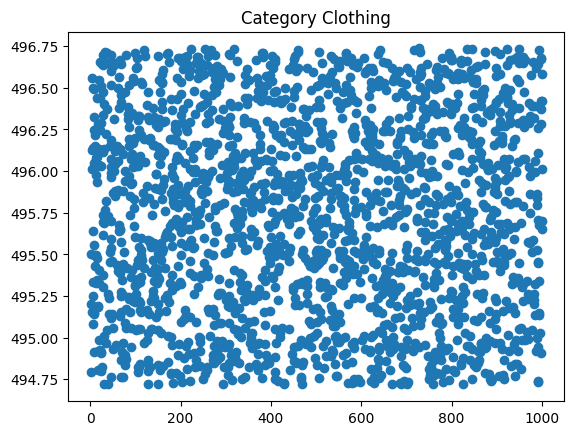

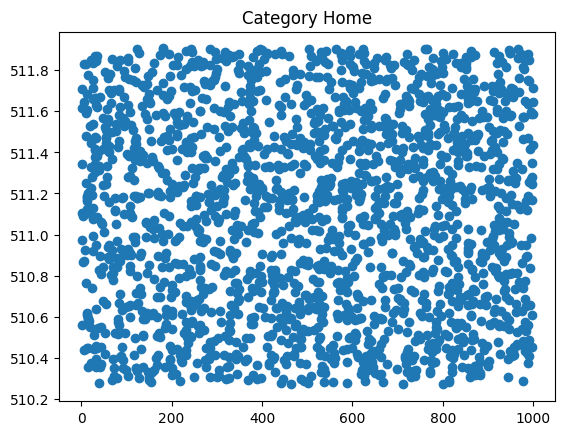

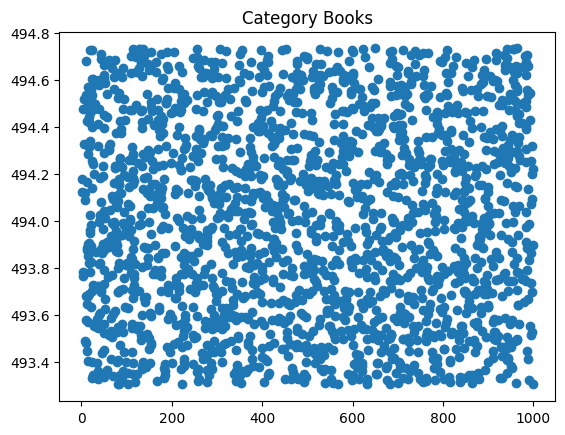

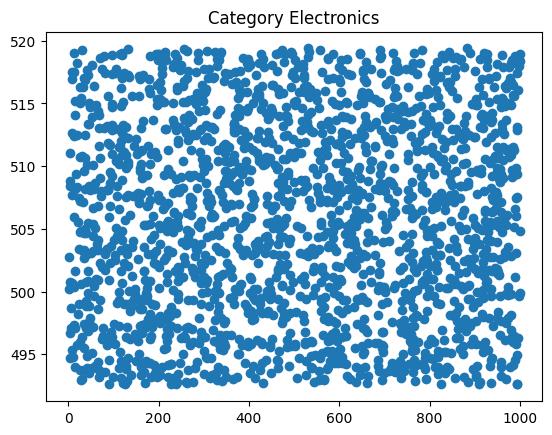

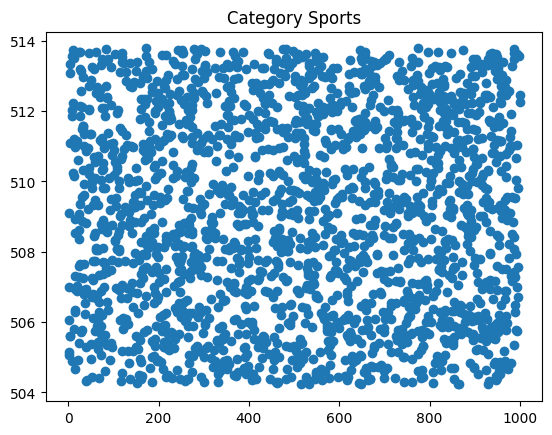

In [41]:
for cat in df['col_7'].unique():
    temp = df[df['col_7'] == cat]

    X = temp[['col_3']]
    y = temp['col_2']

    model = LinearRegression()
    model.fit(X, y)

    pred = model.predict(X)

    plt.scatter(y, pred)
    plt.title(f"Category {cat}")
    plt.show()

In [42]:
#17

In [43]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_absolute_error')

print("MAE CV:", -scores.mean())

MAE CV: 250.45561312748995


In [44]:
#18

In [45]:
def classify(price):
    if price < 100:
        return 0
    elif price < 500:
        return 1
    else:
        return 2

df['price_class'] = df['col_2'].apply(classify)

In [46]:
from sklearn.tree import DecisionTreeClassifier

X = df[['col_3']]
y = df['price_class']

X_train, X_test, y_train, y_test = train_test_split(X, y)

clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

print(clf.score(X_test, y_test))

0.434


In [47]:
#19

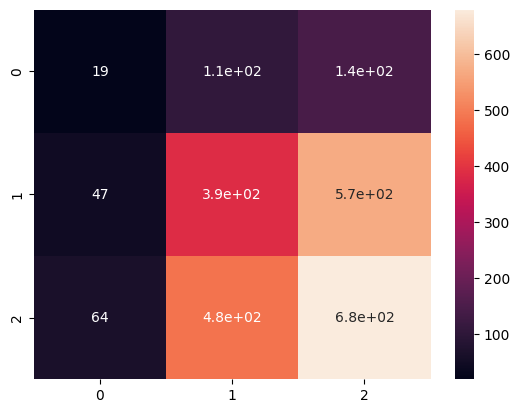

In [48]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True)
plt.show()

In [50]:
#20

In [49]:
df['predicted_price'] = model.predict(X)

df.to_excel("catalog_ml_predictions.xlsx", index=False)